## 1. Mount Google Drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import Libraries

In [13]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 3. Define File Paths

In [14]:
import os

CSV_PATH = "/content/final_fashion_dataset  LAST.csv"
BASE_IMAGE_DIR = "/content/dataset/dataset/images"

cnn_path = "/content/drive/MyDrive/resnet50_fashion_model.keras"
gru_feature_path = "/content/drive/MyDrive/gru_feature_extractor.keras"
tokenizer_path = "/content/drive/MyDrive/tokenizer.pkl"
label_encoder_path = "/content/drive/MyDrive/label_encoder.pkl"

print("CNN exists:", os.path.exists(cnn_path))
print("GRU feature extractor exists:", os.path.exists(gru_feature_path))
print("Tokenizer exists:", os.path.exists(tokenizer_path))
print("Label encoder exists:", os.path.exists(label_encoder_path))

CNN exists: True
GRU feature extractor exists: True
Tokenizer exists: True
Label encoder exists: True


## 4. Extract Dataset from ZIP

In [15]:
import zipfile

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

Dataset extracted


## 5. Load Pretrained Models & Encoders

In [16]:
import pickle

# Load CNN model
cnn_model = tf.keras.models.load_model(
    cnn_path,
    compile=False
)

# Create CNN feature extractor
cnn_feature_model = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[4].output,
    name="cnn_feature_extractor"
)

cnn_feature_model.trainable = False


# Load GRU feature extractor
gru_feature_model = tf.keras.models.load_model(
    gru_feature_path,
    compile=False,
    safe_mode=False
)

gru_feature_model.trainable = False


# Load tokenizer
with open(tokenizer_path, "rb") as f:
    tokenizer = pickle.load(f)


# Load label encoder
with open(label_encoder_path, "rb") as f:
    label_encoder = pickle.load(f)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("CNN feature extractor loaded")
print("GRU feature extractor loaded")
print("Tokenizer loaded")
print("Label encoder loaded")
print("Classes:", class_names)
print("Number of classes:", num_classes)
print("CNN feature shape:", cnn_feature_model.output_shape)
print("GRU feature shape:", gru_feature_model.output_shape)

CNN feature extractor loaded
GRU feature extractor loaded
Tokenizer loaded
Label encoder loaded
Classes: ['bags', 'outfit', 'pants', 'shirts', 'shoes', 'skirt', 'watches']
Number of classes: 7
CNN feature shape: (None, 256)
GRU feature shape: (None, 64)


## 6. Load Dataset CSV

In [17]:
import pandas as pd
import os

CSV_PATH = "/content/final_fashion_dataset  LAST.csv"  # Corrected path

df = pd.read_csv(CSV_PATH, encoding='latin1')

print(df.shape)
print(df.head())
print(df.columns.tolist())

(1211, 3)
                                          image_path  \
0  /content/drive/MyDrive/fashion_dataset/bags/16...   
1  /content/drive/MyDrive/fashion_dataset/bags/11...   
2  /content/drive/MyDrive/fashion_dataset/bags/10...   
3  /content/drive/MyDrive/fashion_dataset/bags/12...   
4  /content/drive/MyDrive/fashion_dataset/bags/11...   

                                         description label  
0     a black handbag with white bow. Category: bags  bags  
1  a blue handbag with a fur ball on the handle. ...  bags  
2  a white and brown handbag on a white backgroun...  bags  
3  a brown and grey bag with two matching bags. C...  bags  
4  a white purse with brown handles and handles. ...  bags  
['image_path', 'description', 'label']


## 7. Fix & Validate Image Paths

In [18]:
import re
# Reload CSV to make sure paths are original
df = pd.read_csv(CSV_PATH, encoding="latin1")

BASE_IMAGE_DIR = "/content/dataset/dataset/images"
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_map_exact = {}
image_map_by_number = {}

def extract_last_number(filename):
    match = re.search(r"(\d+)(?=\.[^.]+$)", filename)
    if match:
        return match.group(1)
    return None

for root, dirs, files in os.walk(BASE_IMAGE_DIR):
    class_name = os.path.basename(root).lower()

    for file in files:
        if file.lower().endswith(valid_extensions):
            full_path = os.path.join(root, file)
            filename = file.lower()

            image_map_exact[(class_name, filename)] = full_path

            number = extract_last_number(filename)
            if number is not None:
                image_map_by_number[(class_name, number)] = full_path

print("Exact image entries:", len(image_map_exact))
print("Number image entries:", len(image_map_by_number))


def fix_image_path(row):
    old_path = str(row["image_path"]).replace("\\", "/")
    label = str(row["label"]).strip().lower()

    filename = os.path.basename(old_path).lower()

    # Existing correct path
    if os.path.exists(old_path):
        folder_class = os.path.basename(os.path.dirname(old_path)).lower()
        if folder_class == label:
            return old_path

    # Exact filename match
    if (label, filename) in image_map_exact:
        return image_map_exact[(label, filename)]

    # Match by last number in filename
    number = extract_last_number(filename)
    if number is not None and (label, number) in image_map_by_number:
        return image_map_by_number[(label, number)]

    return None


df["image_path"] = df.apply(fix_image_path, axis=1)

print("Matched images:", df["image_path"].notna().sum())
print("Unmatched images:", df["image_path"].isna().sum())

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

df["image_exists"] = df["image_path"].apply(os.path.exists)

print(df["image_exists"].value_counts())
print("Dataset after fixing paths:", df.shape)
print("Class distribution:")
print(df["label"].value_counts())
print(df.head())

Exact image entries: 1210
Number image entries: 1174
Matched images: 1192
Unmatched images: 19
image_exists
True    1192
Name: count, dtype: int64
Dataset after fixing paths: (1192, 4)
Class distribution:
label
bags       210
shoes      206
outfit     192
pants      168
shirts     168
skirt      153
watches     95
Name: count, dtype: int64
                                     image_path  \
0   /content/dataset/dataset/images/bags/16.jpg   
1  /content/dataset/dataset/images/bags/112.jpg   
2   /content/dataset/dataset/images/bags/10.jpg   
3  /content/dataset/dataset/images/bags/121.jpg   
4   /content/dataset/dataset/images/bags/11.jpg   

                                         description label  image_exists  
0     a black handbag with white bow. Category: bags  bags          True  
1  a blue handbag with a fur ball on the handle. ...  bags          True  
2  a white and brown handbag on a white backgroun...  bags          True  
3  a brown and grey bag with two matching bags. C..

## 8. Clean Text Descriptions

In [19]:
import re

def clean_description(text):
    text = str(text)

    # Remove "Category: class_name" from the end of description
    text = re.sub(
        r"\s*Category\s*:\s*\w+\s*\.?\s*$",
        "",
        text,
        flags=re.IGNORECASE
    )

    return text.strip()

df["description_clean"] = df["description"].apply(clean_description)

print(df[["description", "description_clean", "label"]].head())

                                         description  \
0     a black handbag with white bow. Category: bags   
1  a blue handbag with a fur ball on the handle. ...   
2  a white and brown handbag on a white backgroun...   
3  a brown and grey bag with two matching bags. C...   
4  a white purse with brown handles and handles. ...   

                                   description_clean label  
0                    a black handbag with white bow.  bags  
1      a blue handbag with a fur ball on the handle.  bags  
2  a white and brown handbag on a white backgroun...  bags  
3       a brown and grey bag with two matching bags.  bags  
4      a white purse with brown handles and handles.  bags  


## 9. Tokenize Text & Encode Labels

In [20]:
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

image_col = "image_path"
text_col = "description_clean"
label_col = "label"

max_len = 25

# Create clean description column if it does not exist
if "description_clean" not in df.columns:
    def clean_description(text):
        text = str(text)
        text = re.sub(
            r"\s*Category\s*:\s*\w+\s*\.?\s*$",
            "",
            text,
            flags=re.IGNORECASE
        )
        return text.strip()

    df["description_clean"] = df["description"].apply(clean_description)

# Clean text and labels
df[text_col] = df[text_col].fillna("").astype(str)
df[label_col] = df[label_col].astype(str).str.strip()

# Keep only valid classes
df = df[df[label_col].isin(class_names)].reset_index(drop=True)

# Convert clean description to sequences
texts = df[text_col].values

text_sequences = tokenizer.texts_to_sequences(texts)

text_padded = pad_sequences(
    text_sequences,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

# Encode labels
label_indices = label_encoder.transform(df[label_col])

labels = tf.keras.utils.to_categorical(
    label_indices,
    num_classes=num_classes
)

# Image paths
image_paths = df[image_col].values

print("Images:", len(image_paths))
print("Text padded shape:", text_padded.shape)
print("Labels shape:", labels.shape)
print("Class distribution:")
print(df[label_col].value_counts())
print("First clean text:", df[text_col].iloc[0])
print("First text sequence:", text_padded[0])
print("First label:", df[label_col].iloc[0], "=>", label_indices[0])

Images: 1192
Text padded shape: (1192, 25)
Labels shape: (1192, 7)
Class distribution:
label
bags       210
shoes      206
outfit     192
pants      168
shirts     168
skirt      153
watches     95
Name: count, dtype: int64
First clean text: a black handbag with white bow.
First text sequence: [  2   4  33  10   5 183   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0]
First label: bags => 0


## 10. Split Data into Train / Validation

In [21]:
X_img_train, X_img_val, X_text_train, X_text_val, y_train, y_val = train_test_split(
    image_paths,
    text_padded,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=label_indices
)

print("Train images:", len(X_img_train))
print("Validation images:", len(X_img_val))
print("Train text shape:", X_text_train.shape)
print("Validation text shape:", X_text_val.shape)
print("Train labels shape:", y_train.shape)
print("Validation labels shape:", y_val.shape)

Train images: 953
Validation images: 239
Train text shape: (953, 25)
Validation text shape: (239, 25)
Train labels shape: (953, 7)
Validation labels shape: (239, 7)


## 11. Build tf.data Pipelines

In [22]:
img_size = (224, 224)
batch_size = 32

def load_multimodal_sample(image_path, text_seq, label):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)

    text_seq = tf.cast(text_seq, tf.int32)
    label = tf.cast(label, tf.float32)

    return {
        "image_input": image,
        "text_input": text_seq
    }, label


train_ds = tf.data.Dataset.from_tensor_slices(
    (X_img_train, X_text_train, y_train)
)

train_ds = train_ds.map(
    load_multimodal_sample,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


val_ds = tf.data.Dataset.from_tensor_slices(
    (X_img_val, X_text_val, y_val)
)

val_ds = val_ds.map(
    load_multimodal_sample,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Train and validation datasets are ready")

Train and validation datasets are ready


## 12. Build Concatenation Model (CNN + GRU)

In [23]:
image_input = layers.Input(
    shape=(224, 224, 3),
    name="image_input"
)

text_input = layers.Input(
    shape=(25,),
    dtype=tf.int32,
    name="text_input"
)

# Extract image features from CNN
image_features = cnn_feature_model(
    image_input,
    training=False
)

# Extract text features from GRU
text_features = gru_feature_model(
    text_input,
    training=False
)

# Concatenate CNN + GRU features
combined = layers.Concatenate(name="concatenation_layer")([
    image_features,
    text_features
])

x = layers.Dense(256, activation="relu")(combined)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(
    num_classes,
    activation="softmax",
    name="final_output"
)(x)

concat_model = models.Model(
    inputs={
        "image_input": image_input,
        "text_input": text_input
    },
    outputs=output,
    name="CNN_GRU_Concatenation_Model"
)

concat_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

concat_model.summary()

Model: "CNN_GRU_Concatenation_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_feature_extrac… │ (None, 256)       │ 24,112,256 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 64)        │  2,642,752 │ text_input[0][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenation_layer │ (None, 320)       │          0 │ cnn_feature_extr… │
│ (Concatenate)       │                   │            │ functional_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     82,176 │ concatenation_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_output        │ (None, 7)         │        903 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,870,983 (102.50 MB)

 Trainable params: 115,975 (453.03 KB)

 Non-trainable params: 26,755,008 (102.06 MB)

## 13. Train the Model

In [24]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_concatenation_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history = concat_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 724ms/step - accuracy: 0.2298 - loss: 2.1142 - val_accuracy: 0.8201 - val_loss: 1.0851
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 392ms/step - accuracy: 0.4785 - loss: 1.3648 - val_accuracy: 0.9498 - val_loss: 0.5954
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 581ms/step - accuracy: 0.6863 - loss: 0.9579 - val_accuracy: 0.9874 - val_loss: 0.3421
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 497ms/step - accuracy: 0.8038 - loss: 0.6456 - val_accuracy: 0.9916 - val_loss: 0.2001
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 459ms/step - accuracy: 0.8478 - loss: 0.5285 - val_accuracy: 0.9916 - val_loss: 0.1247
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 376ms/step - accuracy: 0.9024 - loss: 0.3792 - val_accuracy: 0.9958 - val_loss: 0.0826
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 417ms/step - accuracy: 0.9255 - loss: 0.3003 - val_accuracy: 0.9958 - val_loss: 0.0591
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 345ms/step - accuracy: 0.9328 - loss: 0.2601 - val_accu

## 14. Evaluate on Validation Set

In [26]:
val_loss, val_acc = concat_model.evaluate(val_ds, verbose=2)

print("Concatenation Validation Accuracy:", val_acc)
print("Concatenation Validation Loss:", val_loss)

8/8 - 4s - 515ms/step - accuracy: 0.9958 - loss: 0.0316
Concatenation Validation Accuracy: 0.9958158731460571
Concatenation Validation Loss: 0.031563956290483475


## 15. Classification Report

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_pred_probs = concat_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = []

for inputs, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 607ms/step
              precision    recall  f1-score   support

        bags       1.00      1.00      1.00        42
      outfit       0.97      1.00      0.99        38
       pants       1.00      1.00      1.00        34
      shirts       1.00      0.97      0.99        34
       shoes       1.00      1.00      1.00        41
       skirt       1.00      1.00      1.00        31
     watches       1.00      1.00      1.00        19

    accuracy                           1.00       239
   macro avg       1.00      1.00      1.00       239
weighted avg       1.00      1.00      1.00       239



## 16. Plot Training Curves

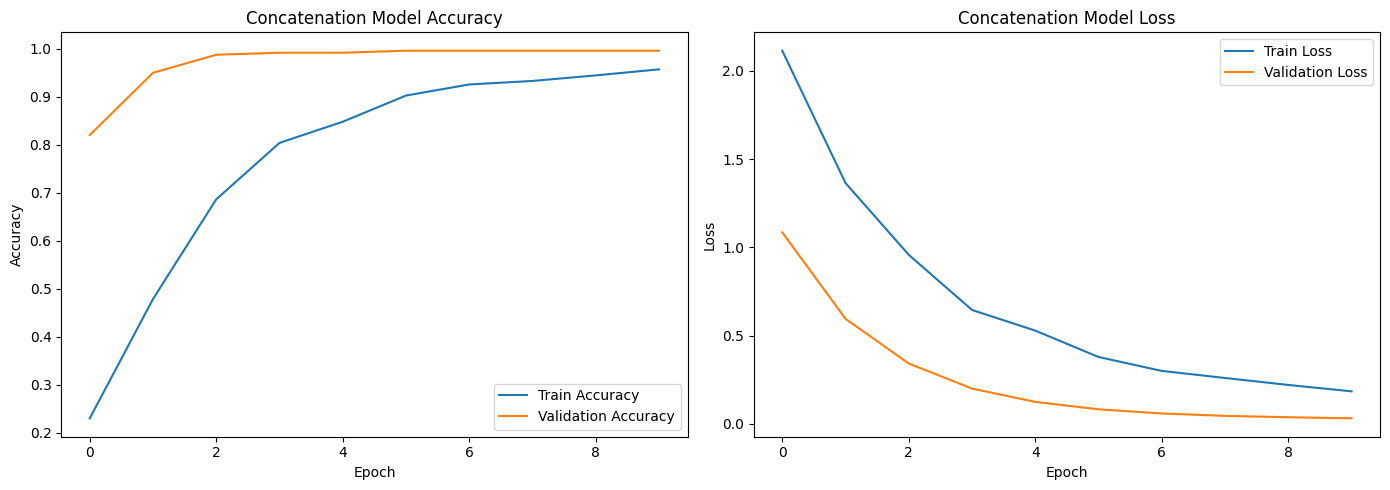

In [28]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Concatenation Model Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Concatenation Model Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 17. Single-Sample Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


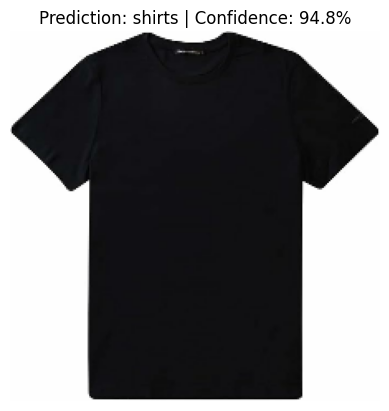

Description: black t-shirt for men
Predicted Class: shirts
Confidence: 94.8%


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# مسار الصورة
test_image_path = "/content/drive/MyDrive/test_image.jpg"

# وصف الصورة
test_description = "black t-shirt for men"

# Load image
img = tf.io.read_file(test_image_path)
img = tf.io.decode_image(img, channels=3, expand_animations=False)
img = tf.image.resize(img, (224, 224))
img = tf.cast(img, tf.float32)

img_array = np.expand_dims(img.numpy(), axis=0)

# Prepare text
test_sequence = tokenizer.texts_to_sequences([test_description])

test_padded = pad_sequences(
    test_sequence,
    maxlen=25,
    padding="post",
    truncating="post"
)

# Prediction
prediction = concat_model.predict({
    "image_input": img_array,
    "text_input": test_padded
})

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction) * 100

plt.imshow(img_array[0].astype("uint8"))
plt.axis("off")
plt.title(f"Prediction: {predicted_class} | Confidence: {confidence:.1f}%")
plt.show()

print("Description:", test_description)
print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence:.1f}%")

## 18. Save the Model

In [30]:
concat_model.save("/content/drive/MyDrive/final_concatenation_model.keras")

print("Concatenation model saved successfully")

Concatenation model saved successfully


## 19. Reload Model & Encoders

In [ ]:
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences

concat_model_path = "/content/drive/MyDrive/best_concatenation_model.keras"
tokenizer_path = "/content/drive/MyDrive/tokenizer.pkl"
label_encoder_path = "/content/drive/MyDrive/label_encoder.pkl"

concat_model = tf.keras.models.load_model(
    concat_model_path,
    compile=False,
    safe_mode=False
)

with open(tokenizer_path, "rb") as f:
    tokenizer = pickle.load(f)

with open(label_encoder_path, "rb") as f:
    label_encoder = pickle.load(f)

class_names = list(label_encoder.classes_)

print("Concatenation model loaded")
print("Classes:", class_names)

# Similarity Model


## 20. Define Similarity Model Paths

In [31]:
cnn_path = "/content/drive/MyDrive/resnet50_fashion_model.keras"

CSV_PATH = "/content/final_fashion_dataset  LAST.csv"
BASE_IMAGE_DIR = "/content/dataset/dataset/images"

print("CNN exists:", os.path.exists(cnn_path))
print("CSV exists:", os.path.exists(CSV_PATH))
print("Images folder exists:", os.path.exists(BASE_IMAGE_DIR))

CNN exists: True
CSV exists: True
Images folder exists: True


## 21. Extract Dataset (Similarity Section)

In [32]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


## 22. Inspect Dataset Folder Structure

In [33]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    if len(image_files) > 0:
        print(root, "=>", len(image_files))

/content/dataset/dataset/images/shirts => 168
/content/dataset/dataset/images/pants => 168
/content/dataset/dataset/images/skirt => 156
/content/dataset/dataset/images/bags => 212
/content/dataset/dataset/images/watches => 106
/content/dataset/dataset/images/outfit => 192
/content/dataset/dataset/images/shoes => 208


## 23. Build CNN Feature Extractor

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model

# لو cnn_feature_model مش متعرف، حمّل CNN واعمل feature extractor
cnn_path = "/content/drive/MyDrive/resnet50_fashion_model.keras"

cnn_model = tf.keras.models.load_model(
    cnn_path,
    compile=False
)

cnn_feature_model = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[4].output,
    name="cnn_feature_extractor"
)

cnn_feature_model.trainable = False

print("CNN feature model ready")
print("Feature shape:", cnn_feature_model.output_shape)

CNN feature model ready
Feature shape: (None, 256)


## 24. Extract Image Features

In [35]:
img_size = (224, 224)
batch_size = 32

image_paths = df["image_path"].values.astype(str)

print("Valid images:", len(image_paths))

def load_image_for_similarity(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(
        img,
        channels=3,
        expand_animations=False
    )
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    return img

image_ds = tf.data.Dataset.from_tensor_slices(image_paths)

image_ds = image_ds.map(
    load_image_for_similarity,
    num_parallel_calls=tf.data.AUTOTUNE
)

image_ds = image_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

features = cnn_feature_model.predict(image_ds, verbose=1)

print("Features shape:", features.shape)

Valid images: 1192
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step
Features shape: (1192, 256)


## 25. Normalize & Save Feature Index

In [36]:
# Normalize features for cosine similarity
features_norm = features / np.linalg.norm(features, axis=1, keepdims=True)

print("Normalized features shape:", features_norm.shape)

# Save features
np.save("/content/drive/MyDrive/similarity_features.npy", features_norm)

# Save image info
df[["image_path", "description", "label"]].to_csv(
    "/content/drive/MyDrive/similarity_index.csv",
    index=False
)

print("Similarity index saved successfully")

Normalized features shape: (1192, 256)
Similarity index saved successfully


## 26. Run Similarity Search & Visualize Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


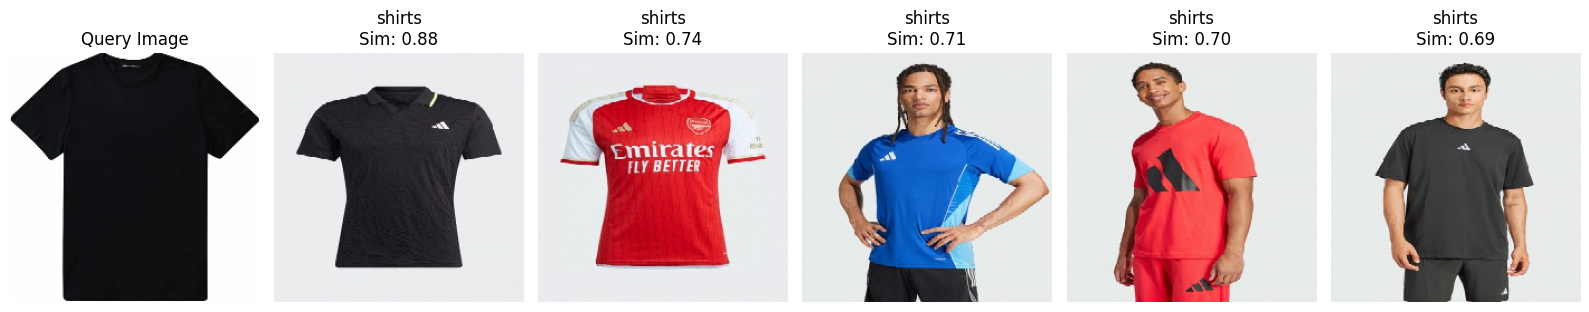

Top Similar Images:
1 | Label: shirts | Similarity: 0.8755 | Path: /content/dataset/dataset/images/shirts/adidas_Поло_AEROREADY_FreeLift_Pro_Tennis_8671.jpg
2 | Label: shirts | Similarity: 0.7375 | Path: /content/dataset/dataset/images/shirts/adidas_Футболка_Arsenal_2324_Home_7474.jpg
3 | Label: shirts | Similarity: 0.7119 | Path: /content/dataset/dataset/images/shirts/adidas_Футболка_спортивная_Tiro_25_Competition_7249.jpg
4 | Label: shirts | Similarity: 0.703 | Path: /content/dataset/dataset/images/shirts/adidas_Футболка_Essentials_Big_Logo_4555.jpg
5 | Label: shirts | Similarity: 0.6904 | Path: /content/dataset/dataset/images/shirts/adidas_Футболка_спортивная_Climacool_One_Rep_at_a_Time_Training_Graphic_2917.jpg


In [37]:
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

test_image_path = "/content/drive/MyDrive/test_image.jpg"
top_k = 5

def extract_query_feature(img_path):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_image(
        img,
        channels=3,
        expand_animations=False
    )
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)

    img_array = np.expand_dims(img.numpy(), axis=0)

    query_feature = cnn_feature_model.predict(img_array)

    query_feature = query_feature / np.linalg.norm(
        query_feature,
        axis=1,
        keepdims=True
    )

    return img_array[0], query_feature


query_img, query_feature = extract_query_feature(test_image_path)

similarities = cosine_similarity(query_feature, features_norm)[0]

top_indices = np.argsort(similarities)[::-1][:top_k]

plt.figure(figsize=(16, 5))

# Query image
plt.subplot(1, top_k + 1, 1)
plt.imshow(query_img.astype("uint8"))
plt.axis("off")
plt.title("Query Image")

# Similar images
for i, idx in enumerate(top_indices):
    sim_img_path = df.iloc[idx]["image_path"]
    sim_label = df.iloc[idx]["label"]
    sim_score = similarities[idx]

    sim_img = image.load_img(sim_img_path, target_size=(224, 224))

    plt.subplot(1, top_k + 1, i + 2)
    plt.imshow(sim_img)
    plt.axis("off")
    plt.title(f"{sim_label}\nSim: {sim_score:.2f}")

plt.tight_layout()
plt.show()

print("Top Similar Images:")
for rank, idx in enumerate(top_indices, start=1):
    print(
        rank,
        "| Label:", df.iloc[idx]["label"],
        "| Similarity:", round(similarities[idx], 4),
        "| Path:", df.iloc[idx]["image_path"]
    )